# Comparing `plant_lookup_complete` vs `plant_matcher_output`
### Name → coordinate matching: how similar are the two outputs, and where do they diverge?

This notebook compares two artefacts produced by the redispatch plant-geocoding
pipeline:

| File | What it is | Name column | Coordinate column(s) |
|---|---|---|---|
| **`plant_lookup_complete_with_coords.csv`** | The *curated / downstream* lookup table. Coordinates come either from a PyPSA match or from a geocoding step, and many rows were re-checked (`source = claude`, `mastr_verified`, …). | `redispatch_name` | `pypsa_lat/lon` **or** `geocoded_lat/lon` (mutually exclusive) |
| **`plant_matcher_output.xlsx`** | The *raw matcher* output from `plant_matcher.py` — one row per redispatch plant, every matching stage (OPSD / PSA / Wikipedia / DDG / gazetteer / state) recorded independently, plus a `final_*` decision. | `plant_name` | `final_lat/lon` |

**The question we answer:** for each plant *name*, did the two methods (a) both
produce a coordinate, and (b) place the plant in the *same location*?  We quantify
agreement with the great-circle (haversine) distance between the two coordinates
and bucket every plant into a clear agreement class.

> Self-contained: only `pandas`, `numpy`, `matplotlib`. No network access.

## 1 · Setup and load

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)

# Files live next to this notebook. Adjust if you move it.
BASE = Path.cwd()
CSV_PATH  = BASE / "plant_lookup_complete_with_coords.csv"
XLSX_PATH = BASE / "plant_matcher_output.xlsx"

assert CSV_PATH.exists(),  f"missing {CSV_PATH}"
assert XLSX_PATH.exists(), f"missing {XLSX_PATH}"

lookup  = pd.read_csv(CSV_PATH)
matcher = pd.read_excel(XLSX_PATH)

print("lookup  (csv) :", lookup.shape)
print("matcher (xlsx):", matcher.shape)

lookup  (csv) : (580, 22)
matcher (xlsx): (766, 49)


In [2]:
# Peek at the columns that matter for this comparison.
print("LOOKUP columns:\n", list(lookup.columns), "\n")
print("MATCHER columns:\n", list(matcher.columns))

LOOKUP columns:
 ['dataset', 'redispatch_name', 'plant_id', 'matched_name', 'fueltype', 'capacity_mw', 'confidence', 'source', 'needs_review', 'plant_ids', 'geocoded_lat', 'geocoded_lon', 'pypsa_lat', 'pypsa_lon', 'mastr_verified', 'mastr_ids', 'mastr_capacity_mw', 'mastr_turbine_count', 'mastr_pypsa_ratio', 'previous_match_plant_ids', 'previous_match_capacity_mw', 'reasoning'] 

MATCHER columns:
 ['plant_name', 'final_confidence', 'final_source', 'final_lat', 'final_lon', 'primaerenergieart', 'cleaned_name', 'place_tokens', 'aggregation', 'opsd_match', 'opsd_score', 'opsd_energy_match', 'opsd_matched_name', 'opsd_lat', 'opsd_lon', 'opsd_class', 'psa_match', 'psa_score', 'psa_energy_match', 'psa_matched_name', 'psa_lat', 'psa_lon', 'psa_class', 'psa_capacity', 'psa_n_candidates', 'wiki_match', 'wiki_title', 'wiki_lat', 'wiki_lon', 'wiki_url', 'wiki_reason', 'ddg_match', 'ddg_title', 'ddg_lat', 'ddg_lon', 'ddg_url', 'ddg_reason', 'gaz_match', 'gaz_place', 'gaz_state', 'gaz_lat', 'gaz_lo

## 2 · Build a common, comparable frame

Each file stores its name and coordinate differently, so we reduce both to a tidy
3-column view — **name**, **lat**, **lon** — plus the method/confidence metadata we
want to compare.

* **Lookup coordinate** = `pypsa_lat/lon` if present, else `geocoded_lat/lon`
  (the two are mutually exclusive in this file). We also keep a `coord_kind`
  flag recording which source supplied it.
* **Matcher coordinate** = `final_lat/lon`.

We join on the plant name. Raw names already overlap heavily, but to avoid
spurious "name only in one file" rows caused by trivial differences (case,
umlaut folding, punctuation) we also compute a **normalised join key** reusing
the same folding logic as `plant_matcher.py`.

In [3]:
def ascii_fold(s: str) -> str:
    s = str(s).lower()
    s = (s.replace("ß", "ss").replace("ä", "ae")
           .replace("ö", "oe").replace("ü", "ue"))
    s = "".join(c for c in unicodedata.normalize("NFKD", s)
                if not unicodedata.combining(c))
    return s

def norm_key(s) -> str:
    # Lowercase, ASCII-folded, alphanumeric-only key (matches plant_matcher.norm)
    if pd.isna(s):
        return ""
    return re.sub(r"[^a-z0-9]+", "", ascii_fold(s))

# --- Lookup side -----------------------------------------------------------
L = pd.DataFrame({
    "name": lookup["redispatch_name"].astype(str).str.strip(),
})
L["lat"] = lookup["pypsa_lat"].combine_first(lookup["geocoded_lat"])
L["lon"] = lookup["pypsa_lon"].combine_first(lookup["geocoded_lon"])
L["coord_kind"] = np.where(lookup["pypsa_lat"].notna(), "pypsa",
                    np.where(lookup["geocoded_lat"].notna(), "geocoded", "none"))
L["source"]     = lookup["source"]
L["confidence"] = lookup["confidence"]
L["key"] = L["name"].map(norm_key)

# --- Matcher side ----------------------------------------------------------
M = pd.DataFrame({
    "name": matcher["plant_name"].astype(str).str.strip(),
    "lat":  matcher["final_lat"],
    "lon":  matcher["final_lon"],
    "source":     matcher["final_source"],
    "confidence": matcher["final_confidence"],
})
M["key"] = M["name"].map(norm_key)

print("lookup rows :", len(L), "| unique keys:", L['key'].nunique())
print("matcher rows:", len(M), "| unique keys:", M['key'].nunique())
L.head()

lookup rows : 580 | unique keys: 576
matcher rows: 766 | unique keys: 753


,name,lat,lon,coord_kind,source,confidence,key
0,Börse,NaN,NaN,none,aggregated,NaN,boerse
1,SHN Cluster Süderdonn T411,54.12,8.75,geocoded,mastr_match,medium,shnclustersuederdonnt411
2,SHN Cluster Süderdonn T412 T413,54.12,8.75,geocoded,mastr_match,medium,shnclustersuederdonnt412t413
3,SHN Cluster Klixbüll,54.78,8.95,geocoded,cluster_match,high,shnclusterklixbuell
4,SHN Cluster Heide West T411 T412,54.20,9.05,geocoded,cluster_match,medium,shnclusterheidewestt411t412


In [4]:
# Guard against duplicate keys collapsing rows silently in the merge.
for nm, df in [("lookup", L), ("matcher", M)]:
    dup = df["key"].duplicated().sum()
    if dup:
        print(f"[warn] {nm}: {dup} duplicate normalised keys (will keep first)")
    else:
        print(f"{nm}: keys are unique")

L1 = L.drop_duplicates("key", keep="first")
M1 = M.drop_duplicates("key", keep="first")

[warn] lookup: 4 duplicate normalised keys (will keep first)
[warn] matcher: 13 duplicate normalised keys (will keep first)


## 3 · Coverage — which names appear where, and which actually got a coordinate

Two different notions of "covered":

1. **Name present** in the file at all.
2. **Name resolved** = present *and* carrying a non-null coordinate.

A file can list a plant but leave it without coordinates (aggregated nodes,
unresolvable market constructs, etc.), so these two counts differ.

In [5]:
keys_L = set(L1["key"])
keys_M = set(M1["key"])

both      = keys_L & keys_M
only_L    = keys_L - keys_M
only_M    = keys_M - keys_L

print("=== Name presence (normalised key) ===")
print(f"in BOTH files      : {len(both)}")
print(f"only in lookup csv : {len(only_L)}")
print(f"only in matcher xls: {len(only_M)}")

has_coord_L = set(L1.loc[L1['lat'].notna(), 'key'])
has_coord_M = set(M1.loc[M1['lat'].notna(), 'key'])
print("\n=== Resolved (has a coordinate) ===")
print(f"lookup  resolved : {len(has_coord_L)} / {len(L1)}  "
      f"({len(has_coord_L)/len(L1):.0%})")
print(f"matcher resolved : {len(has_coord_M)} / {len(M1)}  "
      f"({len(has_coord_M)/len(M1):.0%})")

=== Name presence (normalised key) ===
in BOTH files      : 567
only in lookup csv : 9
only in matcher xls: 186

=== Resolved (has a coordinate) ===
lookup  resolved : 451 / 576  (78%)
matcher resolved : 680 / 753  (90%)


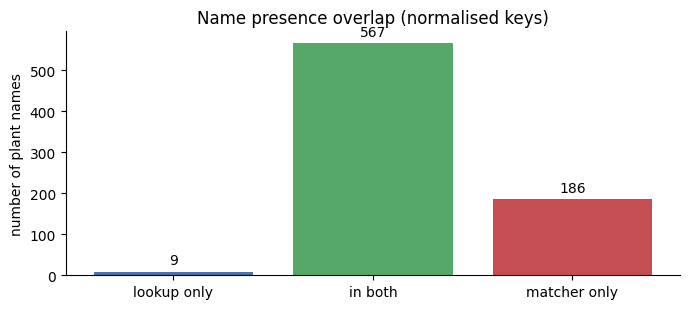

In [6]:
# Visualise name-presence overlap as a simple 3-bar 'Venn-by-counts'.
fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ["lookup only", "in both", "matcher only"]
vals   = [len(only_L), len(both), len(only_M)]
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(labels, vals, color=colors)
ax.bar_label(bars, padding=3)
ax.set_ylabel("number of plant names")
ax.set_title("Name presence overlap (normalised keys)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [7]:
# What are the names that live in only one file? (capped preview)
print(">>> Names ONLY in lookup csv:")
display(L1[L1['key'].isin(only_L)][['name','source','coord_kind']]
        .sort_values('name').reset_index(drop=True))

print(">>> Names ONLY in matcher xlsx (first 40 of "
      f"{len(only_M)}):")
display(M1[M1['key'].isin(only_M)][['name','source','confidence']]
        .sort_values('name').head(40).reset_index(drop=True))

>>> Names ONLY in lookup csv:


,name,source,coord_kind
0,50H_EDIS_CR_LV_NORD,aggregated,none
1,50H_EDIS_CR_LV_WU,aggregated,none
2,50H_MNS_CR_LV_OST,aggregated,none
3,Börse,aggregated,none
4,CROC Cluster Perleberg,mastr_match,geocoded
5,Hannover-Linden GuD,claude,pypsa
6,"Heizkraftwerk Stuttgart-Münster GT 16,17,18",claude,pypsa
7,Heizkraftwerk Stuttgart-Münster GT 87,claude,pypsa
8,INFRA_HOE_GTX8,claude,pypsa


>>> Names ONLY in matcher xlsx (first 40 of 186):


,name,source,confidence
0,10YDE-RWENET---I,skipped_grid_area_market,0.00
1,Abschaltbare Last (RZ TenneT DE),skipped_grid_area_market,0.00
2,Amprion Abruf abschaltbare Lasten,skipped_grid_area_market,0.00
3,Amprion NR BK,skipped_grid_area_market,0.00
4,Auslaendische-Netzreserve,skipped_grid_area_market,0.00
5,BASF KW-Park,grid_area_dso,0.20
6,Bergkamen,opsd_exact,1.00
7,Bexbach,opsd_exact,1.00
8,Bl. C,unresolved,0.00
9,Boxberg,opsd_exact,1.00


## 4 · Coordinate agreement on shared names

For every name present in **both** files we compute the great-circle distance
between the lookup coordinate and the matcher coordinate. This is the heart of
the comparison: small distance ⇒ the two pipelines agree on *where* the plant is;
large distance ⇒ a genuine disagreement worth inspecting.

In [8]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Outer-join the two tidy frames on the normalised key.
merged = L1.merge(M1, on="key", how="outer", suffixes=("_lkp", "_mat"))

merged["both_have_coord"] = merged["lat_lkp"].notna() & merged["lat_mat"].notna()
merged["dist_km"] = np.where(
    merged["both_have_coord"],
    haversine_km(merged["lat_lkp"], merged["lon_lkp"],
                 merged["lat_mat"], merged["lon_mat"]),
    np.nan,
)
print("plants comparable on coordinates (both have coords):",
      int(merged["both_have_coord"].sum()))
merged["dist_km"].describe()

plants comparable on coordinates (both have coords): 418


count    418.000000
mean      32.853337
std       97.208962
min        0.000000
25%        0.232842
50%        1.248749
75%       10.150606
max      705.272686
Name: dist_km, dtype: float64

In [9]:
# Classify every plant into one mutually-exclusive agreement bucket.
def classify(r):
    in_L = pd.notna(r["name_lkp"])
    in_M = pd.notna(r["name_mat"])
    if in_L and not in_M:
        return "name only in lookup"
    if in_M and not in_L:
        return "name only in matcher"
    # in both files:
    cL, cM = pd.notna(r["lat_lkp"]), pd.notna(r["lat_mat"])
    if not cL and not cM:
        return "shared, neither has coord"
    if cL and not cM:
        return "shared, only lookup has coord"
    if cM and not cL:
        return "shared, only matcher has coord"
    d = r["dist_km"]
    if d < 1:    return "agree  < 1 km"
    if d < 10:   return "agree  1–10 km"
    if d < 50:   return "diverge 10–50 km"
    return "DISAGREE > 50 km"

merged["agreement"] = merged.apply(classify, axis=1)

ORDER = [
    "agree  < 1 km", "agree  1–10 km", "diverge 10–50 km", "DISAGREE > 50 km",
    "shared, only lookup has coord", "shared, only matcher has coord",
    "shared, neither has coord",
    "name only in lookup", "name only in matcher",
]
counts = merged["agreement"].value_counts().reindex(ORDER).fillna(0).astype(int)
counts.to_frame("plants")

,plants
agreement,
agree < 1 km,202
agree 1–10 km,106
diverge 10–50 km,62
DISAGREE > 50 km,48
"shared, only lookup has coord",28
"shared, only matcher has coord",111
"shared, neither has coord",10
name only in lookup,9
name only in matcher,186


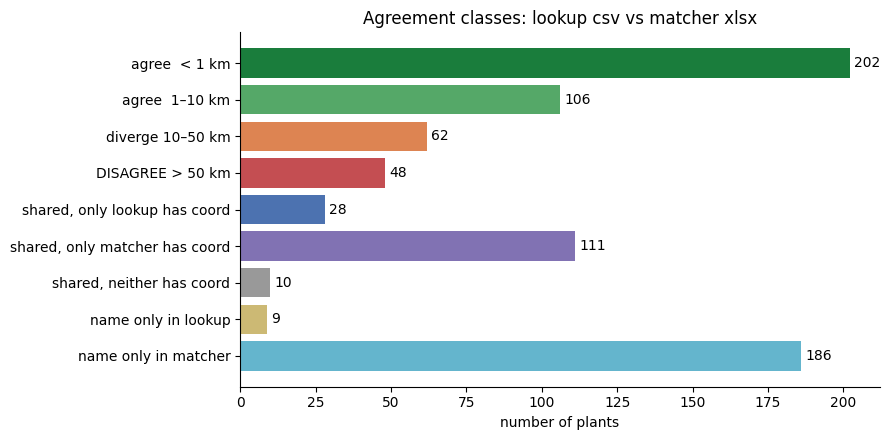

In [10]:
# Bar chart of the agreement classes.
fig, ax = plt.subplots(figsize=(9, 4.5))
palette = {
    "agree  < 1 km": "#1a7d3c", "agree  1–10 km": "#55A868",
    "diverge 10–50 km": "#DD8452", "DISAGREE > 50 km": "#C44E52",
    "shared, only lookup has coord": "#4C72B0",
    "shared, only matcher has coord": "#8172B3",
    "shared, neither has coord": "#999999",
    "name only in lookup": "#CCB974", "name only in matcher": "#64B5CD",
}
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=[palette[k] for k in counts.index[::-1]])
ax.bar_label(bars, padding=3)
ax.set_xlabel("number of plants")
ax.set_title("Agreement classes: lookup csv vs matcher xlsx")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

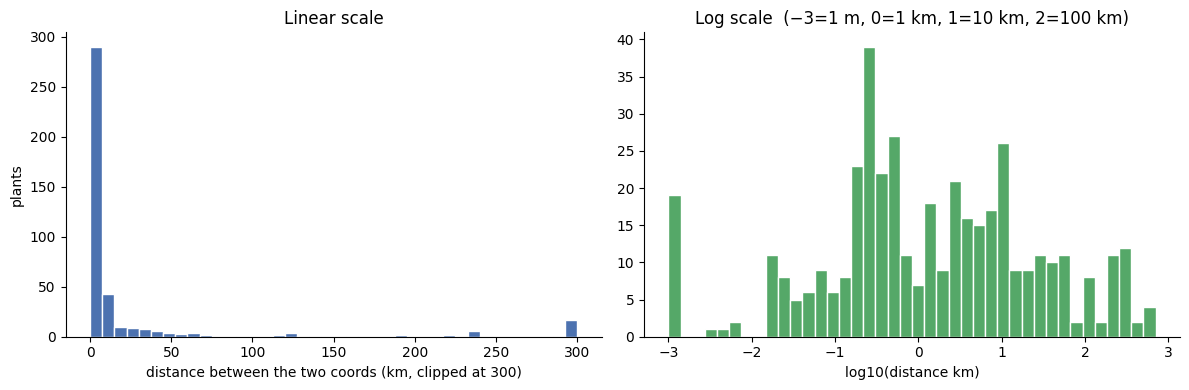

  within    0.1 km :  15.6%  (65 plants)
  within    0.5 km :  42.1%  (176 plants)
  within    1.0 km :  48.3%  (202 plants)
  within    5.0 km :  66.0%  (276 plants)
  within   10.0 km :  73.7%  (308 plants)
  within   25.0 km :  82.8%  (346 plants)
  within   50.0 km :  88.5%  (370 plants)
  within  100.0 km :  90.9%  (380 plants)


In [11]:
# Distance distribution for the comparable plants (log-scaled x).
comp = merged[merged["both_have_coord"]].copy()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

a1.hist(comp["dist_km"].clip(upper=300), bins=40, color="#4C72B0", edgecolor="white")
a1.set_xlabel("distance between the two coords (km, clipped at 300)")
a1.set_ylabel("plants"); a1.set_title("Linear scale")
a1.spines[["top","right"]].set_visible(False)

pos = comp["dist_km"].clip(lower=1e-3)
a2.hist(np.log10(pos), bins=40, color="#55A868", edgecolor="white")
a2.set_xlabel("log10(distance km)")
a2.set_title("Log scale  (−3=1 m, 0=1 km, 1=10 km, 2=100 km)")
a2.spines[["top","right"]].set_visible(False)

plt.tight_layout(); plt.show()

# Cumulative agreement: share of comparable plants within X km.
for thr in [0.1, 0.5, 1, 5, 10, 25, 50, 100]:
    share = (comp["dist_km"] <= thr).mean()
    print(f"  within {thr:6.1f} km : {share:6.1%}  "
          f"({int((comp['dist_km']<=thr).sum())} plants)")

## 5 · Where they disagree — drill-down tables

The interesting rows for QA are the ones where both files placed the plant but
**far apart**. These are the candidates for manual review: a wrong OPSD/PSA name
hit, an ambiguous city name, or a centroid fallback in one file vs a precise hit
in the other.

In [12]:
cols = ["name_lkp", "dist_km",
        "source_lkp", "coord_kind", "confidence_lkp",
        "source_mat", "confidence_mat",
        "lat_lkp", "lon_lkp", "lat_mat", "lon_mat"]

disagree = (comp[comp["dist_km"] >= 10]
            .sort_values("dist_km", ascending=False)[cols]
            .reset_index(drop=True))
print(f"{len(disagree)} plants disagree by >= 10 km\n")
display(disagree.head(40))

110 plants disagree by >= 10 km



,name_lkp,dist_km,source_lkp,coord_kind,confidence_lkp,source_mat,confidence_mat,lat_lkp,lon_lkp,lat_mat,lon_mat
0,Silz 2 (Uniper),705.272686,geocoded_unmatched,geocoded,none,gazetteer,0.500,47.266700,10.766700,53.519500,12.440000
1,Silz 1 (TIWAG),703.725535,geocoded_unmatched,geocoded,none,gazetteer,0.500,47.264000,10.930000,53.519500,12.440000
2,Silz 1 (Uniper),703.469716,mastr_match,geocoded,none,gazetteer,0.500,47.313300,10.508300,53.519500,12.440000
3,Silz 2 (TIWAG),703.469716,mastr_match,geocoded,none,gazetteer,0.500,47.313300,10.508300,53.519500,12.440000
4,BAG NWAK-Cluster 10 Oberbachern,493.007276,geocoded_cluster,geocoded,medium,nominatim,0.400,51.583300,6.766700,48.282029,11.368700
5,SHN Cluster Krümmel,405.355552,cluster_match,geocoded,medium,gazetteer,0.500,53.790000,10.410000,50.537200,7.724700
6,SHN Cluster Audorf Süd,336.233264,mastr_match,geocoded,medium,psa_fuzzy_dir,0.654,54.370000,9.370000,51.363309,8.837303
7,AVA Cluster Elsen,334.852816,mastr_match,geocoded,medium,psa_fuzzy,0.727,51.970000,8.740000,49.213875,6.827617
8,Tanzmühle,331.655962,geocoded_match,geocoded,medium,psa_fuzzy,0.758,52.382900,10.787900,49.552216,12.281256
9,BAG NWAK-Cluster 17 Altheim,327.815007,mastr_match,geocoded,medium,opsd_exact,1.000,48.750000,12.880000,51.536513,14.382898


In [13]:
# Which method pairings produce the disagreements?  Cross-tab of sources
# among the >10 km divergences highlights systematic mismatches
# (e.g. lookup 'claude/pypsa' vs matcher 'gazetteer' centroid).
if len(disagree):
    ct = (disagree.assign(bucket=pd.cut(disagree["dist_km"],
              [10, 50, 200, 1e9], labels=["10–50", "50–200", ">200"]))
          .pivot_table(index="source_lkp", columns="source_mat",
                       values="name_lkp", aggfunc="count", fill_value=0))
    display(ct)

source_mat,gazetteer,grid_area_region,manual,nominatim,opsd_city,opsd_exact,psa_exact,psa_exact_dir,psa_fuzzy,psa_fuzzy_dir,unresolved,wikipedia
source_lkp,,,,,,,,,,,,
claude,13,0,4,5,0,0,2,4,3,1,0,4
cluster_match,10,0,0,2,0,0,4,1,1,0,0,3
geocoded_cluster,0,0,0,4,0,0,0,0,0,0,0,0
geocoded_match,1,3,0,5,0,0,0,0,1,0,0,0
geocoded_unmatched,2,0,0,0,0,3,1,0,0,0,0,0
mastr_match,8,1,0,5,2,5,2,1,4,2,2,1


In [14]:
# Plants resolved by exactly one of the two files (present in both, one coord).
only_lkp_coord = merged[merged["agreement"] == "shared, only lookup has coord"]
only_mat_coord = merged[merged["agreement"] == "shared, only matcher has coord"]

print(f">>> shared names the MATCHER left without coords but LOOKUP resolved "
      f"({len(only_lkp_coord)}):")
display(only_lkp_coord[["name_lkp","source_lkp","coord_kind",
                        "source_mat"]].head(30).reset_index(drop=True))

print(f">>> shared names the LOOKUP left without coords but MATCHER resolved "
      f"({len(only_mat_coord)}):")
display(only_mat_coord[["name_mat","source_mat","confidence_mat",
                        "source_lkp"]].head(30).reset_index(drop=True))

>>> shared names the MATCHER left without coords but LOOKUP resolved (28):


,name_lkp,source_lkp,coord_kind,source_mat
0,50H InfraLeuna IKW,claude,pypsa,unresolved
1,50H PV Witznitz,claude,pypsa,unresolved
2,AVA Cluster Ohlensehlen,cluster_match,geocoded,unresolved
3,BASF-GESAMTEINSPEISG,geocoded_match,geocoded,skipped_grid_area_market
4,CHEMIEPARK_MARL_KRAFTWERKE,claude,pypsa,unresolved
5,CROC Cluster Görries,geocoded_cluster,geocoded,unresolved
6,EGM_DTS,claude,pypsa,unresolved
7,GAMOR_ROEMER,claude,pypsa,unresolved
8,GTKW-DA-GT11,claude,pypsa,unresolved
9,GTKW-DA-GT12,claude,pypsa,unresolved


>>> shared names the LOOKUP left without coords but MATCHER resolved (111):


,name_mat,source_mat,confidence_mat,source_lkp
0,50H_AVA_CR_FOE,grid_area_dso,0.20,aggregated
1,50H_AVA_CR_STW,grid_area_dso,0.20,aggregated
2,50H_AVA_CR_WK,grid_area_dso,0.20,aggregated
3,50H_AVA_CR_WOL,grid_area_dso,0.20,aggregated
4,50H_EDIS_CR_ATS,grid_area_dso,0.20,aggregated
5,50H_EDIS_CR_BW,grid_area_state,0.25,aggregated
6,50H_EDIS_CR_EH,grid_area_dso,0.20,aggregated
7,50H_EDIS_CR_GSE,grid_area_dso,0.20,aggregated
8,50H_EDIS_CR_GUE_Nord,grid_area_dso,0.15,aggregated
9,50H_EDIS_CR_GUE_Sued,grid_area_dso,0.15,aggregated


## 6 · How the *methods* line up

The two files use different vocabularies for "how was this matched". Cross-tabbing
the source labels on the **agreeing** plants (< 10 km) shows which matcher stage
each lookup category typically corresponds to — useful for understanding the
downstream curation.

In [15]:
agree = merged[merged["agreement"].isin(["agree  < 1 km", "agree  1–10 km"])]
src_ct = pd.crosstab(agree["source_lkp"], agree["source_mat"])
print("Source cross-tab on AGREEING plants (<10 km):")
display(src_ct)

Source cross-tab on AGREEING plants (<10 km):


source_mat,gazetteer,manual,nominatim,opsd_city,opsd_exact,opsd_fuzzy,psa_exact,psa_exact_dir,psa_fuzzy,state_centroid_N,unresolved,wikipedia
source_lkp,,,,,,,,,,,,
claude,24,21,3,8,144,3,42,0,4,0,1,7
cluster_match,7,0,0,0,0,0,1,2,2,1,0,2
geocoded_cluster,1,0,0,1,0,0,0,0,0,0,0,0
geocoded_match,1,1,4,1,7,0,3,0,0,0,0,0
geocoded_unmatched,1,0,0,0,0,0,0,0,0,0,0,0
mastr_match,11,1,0,0,0,0,1,1,2,0,0,0


lookup confidence values:
confidence_lkp
high      265
medium     40
low         2
none        1
Name: count, dtype: int64 

matcher final_confidence on agreeing plants:
count    308.000000
mean       0.870896
std        0.209362
min        0.275000
25%        0.850000
50%        1.000000
75%        1.000000
max        1.000000
Name: confidence_mat, dtype: float64


C:\Users\wachs\AppData\Local\Temp\ipykernel_31548\3309946102.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d for d in data if len(d)],


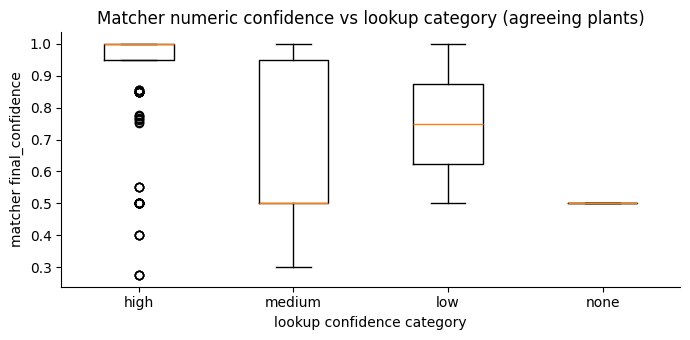

In [16]:
# Confidence: do the two files rate their matches similarly where they agree?
# lookup confidence is categorical (high/medium/...), matcher is numeric [0,1].
print("lookup confidence values:")
print(agree["confidence_lkp"].value_counts(dropna=False), "\n")
print("matcher final_confidence on agreeing plants:")
print(agree["confidence_mat"].describe())

fig, ax = plt.subplots(figsize=(7, 3.5))
order = [c for c in ["high","medium","low","very_low","none"]
         if c in agree["confidence_lkp"].unique()]
data = [agree.loc[agree["confidence_lkp"]==c, "confidence_mat"].dropna()
        for c in order]
if any(len(d) for d in data):
    ax.boxplot([d for d in data if len(d)],
               labels=[c for c,d in zip(order,data) if len(d)],
               vert=True)
    ax.set_ylabel("matcher final_confidence")
    ax.set_xlabel("lookup confidence category")
    ax.set_title("Matcher numeric confidence vs lookup category (agreeing plants)")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

## 7 · Geographic view of the disagreements

Plot the agreeing plants faintly and draw a connecting line for each >10 km
disagreement (lookup point → matcher point). Long lines crossing the country are
the egregious mismatches; short clusters are sub-regional ambiguity.

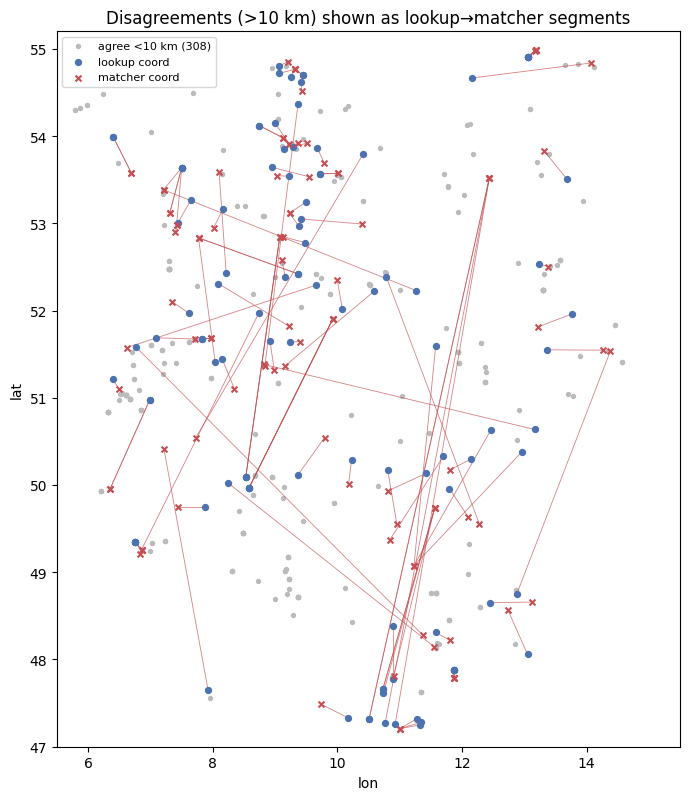

In [17]:
fig, ax = plt.subplots(figsize=(7, 8.5))

ok = comp[comp["dist_km"] < 10]
ax.scatter(ok["lon_lkp"], ok["lat_lkp"], s=8, c="#bbbbbb",
           label=f"agree <10 km ({len(ok)})", zorder=1)

bad = comp[comp["dist_km"] >= 10]
for _, r in bad.iterrows():
    ax.plot([r["lon_lkp"], r["lon_mat"]], [r["lat_lkp"], r["lat_mat"]],
            "-", color="#C44E52", lw=0.6, alpha=0.7, zorder=2)
ax.scatter(bad["lon_lkp"], bad["lat_lkp"], s=18, c="#4C72B0",
           label="lookup coord", zorder=3)
ax.scatter(bad["lon_mat"], bad["lat_mat"], s=18, c="#C44E52",
           marker="x", label="matcher coord", zorder=3)

ax.set_xlim(5.5, 15.5); ax.set_ylim(47, 55.2)
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title("Disagreements (>10 km) shown as lookup→matcher segments")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect(1.4)
plt.tight_layout(); plt.show()

## 8 · Export the full comparison & headline summary

The merged, per-plant comparison table is written to
`comparison_lookup_vs_matcher.csv` so the disagreements can be triaged outside
the notebook.

In [18]:
out_cols = ["name_lkp", "name_mat", "agreement", "dist_km",
            "lat_lkp", "lon_lkp", "source_lkp", "coord_kind", "confidence_lkp",
            "lat_mat", "lon_mat", "source_mat", "confidence_mat"]
export = merged[out_cols].sort_values(
    ["agreement", "dist_km"], ascending=[True, False])
out_path = BASE / "comparison_lookup_vs_matcher.csv"
export.to_csv(out_path, index=False)
print("wrote", out_path, export.shape)

wrote C:\Users\wachs\Documents\TUM\Seminar EM\ALLES_NEU\comparison_lookup_vs_matcher.csv (762, 13)


In [19]:
n_comp = int(merged["both_have_coord"].sum())
agree10 = int((comp["dist_km"] < 10).sum())
med = comp["dist_km"].median()

print("=" * 64)
print("SUMMARY — plant_lookup_complete  vs  plant_matcher_output")
print("=" * 64)
print(f"names in lookup csv          : {len(L1)}")
print(f"names in matcher xlsx        : {len(M1)}")
print(f"shared names                 : {len(both)}")
print(f"  comparable (both coords)   : {n_comp}")
print(f"    agree   < 10 km          : {agree10}  ({agree10/n_comp:.0%} of comparable)")
print(f"    diverge > 10 km          : {n_comp-agree10}")
print(f"  median separation          : {med:.2f} km")
print(f"names only in lookup         : {len(only_L)}")
print(f"names only in matcher        : {len(only_M)}")
print("-" * 64)
for k in ORDER:
    print(f"  {k:34s}: {counts[k]}")

SUMMARY — plant_lookup_complete  vs  plant_matcher_output
names in lookup csv          : 576
names in matcher xlsx        : 753
shared names                 : 567
  comparable (both coords)   : 418
    agree   < 10 km          : 308  (74% of comparable)
    diverge > 10 km          : 110
  median separation          : 1.25 km
names only in lookup         : 9
names only in matcher        : 186
----------------------------------------------------------------
  agree  < 1 km                     : 202
  agree  1–10 km                    : 106
  diverge 10–50 km                  : 62
  DISAGREE > 50 km                  : 48
  shared, only lookup has coord     : 28
  shared, only matcher has coord    : 111
  shared, neither has coord         : 10
  name only in lookup               : 9
  name only in matcher              : 186


### How to read this

* **`agree < 1 km` / `1–10 km`** — the two pipelines independently put the plant
  in the same place. For these the lookup and matcher are interchangeable on the
  name→coordinate question.
* **`diverge 10–50 km` / `DISAGREE > 50 km`** — same name, different location.
  Inspect §5: typically one side took a precise OPSD/PSA hit while the other fell
  back to a city/state/region **centroid**, or an ambiguous name (two "Halle"s)
  resolved differently. The exported CSV lists every one.
* **`only … has coord`** — both files know the plant, but only one geocoded it.
  This is where the lookup's curation (`source = claude`, MaStR verification)
  added or removed coverage relative to the raw matcher.
* **`name only in …`** — the row sets differ. The matcher xlsx is the broader raw
  list; the lookup csv is a filtered/curated subset, which explains most of the
  matcher-only names.

Tweak the bucket thresholds in §4 (`classify`) and the disagreement cut in §5
(`>= 10 km`) to match how tight you need the agreement to be.

---
# 9 · Overview — matcher coordinates with `final_confidence >= 0.5` only

Everything above used **every** matcher coordinate. Here we repeat the *entire*
comparison but **only trust matcher locations whose `final_confidence >= 0.5`**.

A matcher row below the threshold keeps its **name** but has its **coordinate
treated as missing** — so a low-confidence plant doesn't count as "matcher placed
it here". The `>= 0.5` cut keeps the mid-tier fallbacks that land exactly at
`0.50` (gazetteer place hits, state centroids) and discards only what scores
strictly below — weak fuzzy hits, ambiguity-penalised PSA matches, and the
low-confidence grid-area/region guesses. The breakdown cell below lists exactly
which `final_source` values get suppressed.

The cell after that wraps the whole §3–§8 analysis into one function so we can
run it on the filtered matcher frame and read off the same coverage / agreement /
distance / disagreement / map / summary outputs.

In [20]:
MATCHER_MIN_CONFIDENCE = 0.5   # keep matcher coords with final_confidence >= this

def build_matcher_frame(min_conf):
    # Matcher tidy frame, coords nulled where final_confidence < min_conf.
    mm = M1.copy()
    low = mm["confidence"].fillna(-1) < min_conf
    mm.loc[low, ["lat", "lon"]] = np.nan
    return mm, int(low.sum())

M_hi, n_dropped = build_matcher_frame(MATCHER_MIN_CONFIDENCE)
kept = M_hi["lat"].notna().sum()
print(f"matcher rows total               : {len(M1)}")
print(f"coords kept (conf >= {MATCHER_MIN_CONFIDENCE})        : {kept}")
print(f"coords suppressed (conf < {MATCHER_MIN_CONFIDENCE})   : {n_dropped}")
print("\nfinal_source of the SUPPRESSED matcher coords:")
supp = M1.loc[(M1['confidence'].fillna(-1) < MATCHER_MIN_CONFIDENCE)
              & M1['lat'].notna(), 'source']
print(supp.value_counts())

matcher rows total               : 753
coords kept (conf >= 0.5)        : 519
coords suppressed (conf < 0.5)   : 234

final_source of the SUPPRESSED matcher coords:
source
grid_area_dso        79
nominatim            33
grid_area_region     17
grid_area_city        6
manual                5
state_centroid        4
opsd_city             4
psa_exact_dir         2
state_centroid_N      2
psa_exact             1
state_centroid_NE     1
grid_area_state       1
state_centroid_NW     1
state_centroid_S      1
state_centroid_W      1
state_centroid_SE     1
unresolved            1
psa_fuzzy             1
Name: count, dtype: int64


SUMMARY [matcher_conf_ge_0p5]
lookup names                 : 576
matcher names                : 753
shared names                 : 567
  comparable (both coords)   : 378
    agree   < 10 km          : 296  (78% of comparable)
    diverge > 10 km          : 82
  median separation          : 0.64 km
----------------------------------------------------------------
  agree  < 1 km                     : 199
  agree  1–10 km                    : 97
  diverge 10–50 km                  : 52
  DISAGREE > 50 km                  : 30
  shared, only lookup has coord     : 68
  shared, only matcher has coord    : 4
  shared, neither has coord         : 117
  name only in lookup               : 9
  name only in matcher              : 186


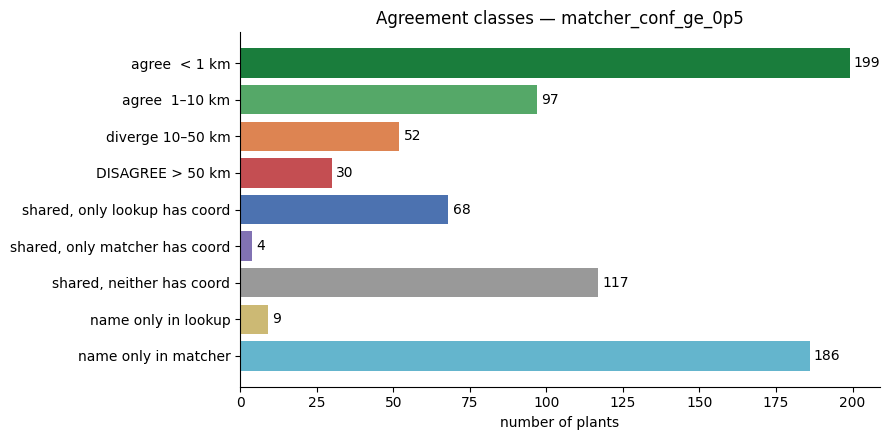

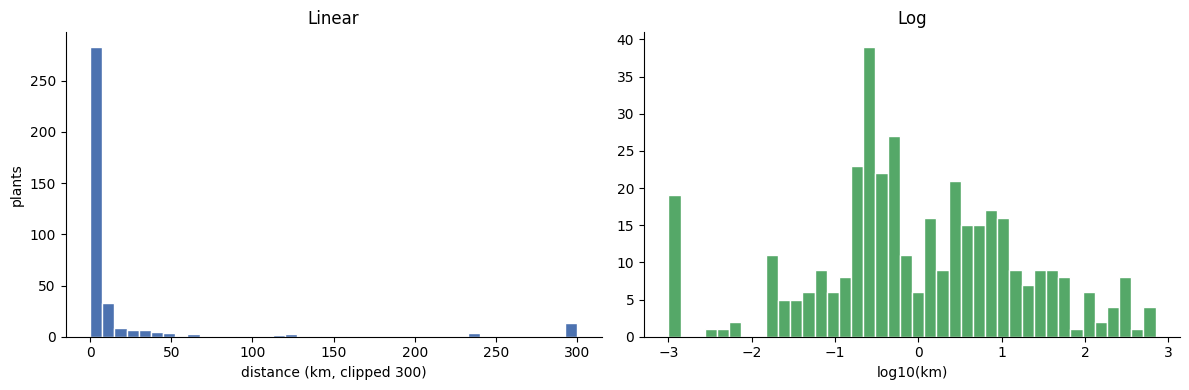

cumulative agreement:
  within    0.1 km :  16.4%  (62)
  within    0.5 km :  45.8%  (173)
  within    1.0 km :  52.6%  (199)
  within    5.0 km :  71.2%  (269)
  within   10.0 km :  78.3%  (296)
  within   25.0 km :  86.5%  (327)
  within   50.0 km :  92.1%  (348)
  within  100.0 km :  93.7%  (354)


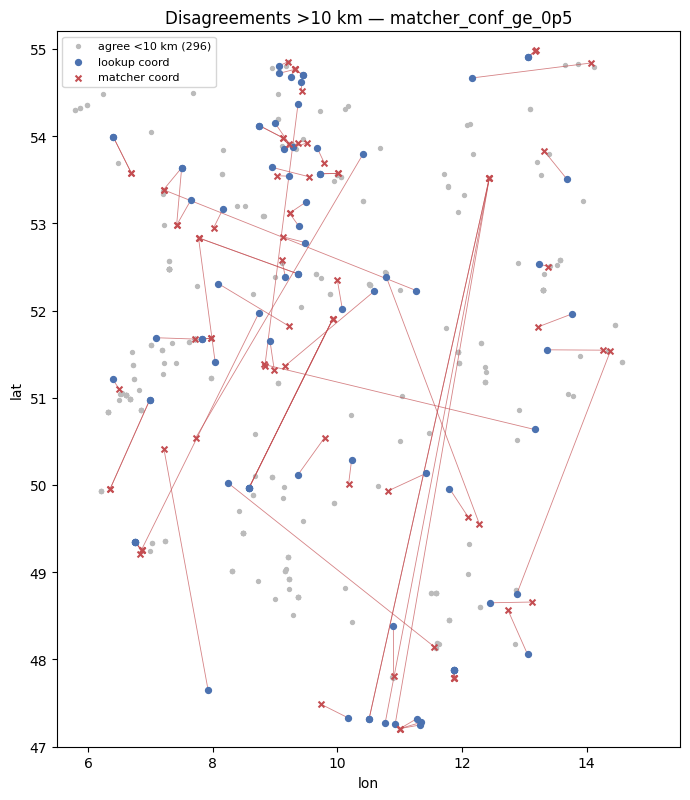


wrote C:\Users\wachs\Documents\TUM\Seminar EM\ALLES_NEU\comparison_matcher_conf_ge_0p5.csv


In [21]:
def run_comparison(L_frame, M_frame, tag, make_plots=True, export=True):
    # Full lookup-vs-matcher comparison on the given frames (mirrors sections
    # 3-8). Returns the merged per-plant table.
    g = L_frame.merge(M_frame, on="key", how="outer", suffixes=("_lkp", "_mat"))
    g["both_have_coord"] = g["lat_lkp"].notna() & g["lat_mat"].notna()
    g["dist_km"] = np.where(
        g["both_have_coord"],
        haversine_km(g["lat_lkp"], g["lon_lkp"], g["lat_mat"], g["lon_mat"]),
        np.nan)
    g["agreement"] = g.apply(classify, axis=1)
    c = g["agreement"].value_counts().reindex(ORDER).fillna(0).astype(int)

    kL = set(L_frame["key"]); kM = set(M_frame["key"])
    shared = kL & kM
    cmp_ = g[g["both_have_coord"]]
    n_cmp = len(cmp_)
    a10 = int((cmp_["dist_km"] < 10).sum())

    # ---- summary ----
    print("=" * 64)
    print(f"SUMMARY [{tag}]")
    print("=" * 64)
    print(f"lookup names                 : {len(L_frame)}")
    print(f"matcher names                : {len(M_frame)}")
    print(f"shared names                 : {len(shared)}")
    print(f"  comparable (both coords)   : {n_cmp}")
    if n_cmp:
        print(f"    agree   < 10 km          : {a10}  ({a10/n_cmp:.0%} of comparable)")
        print(f"    diverge > 10 km          : {n_cmp-a10}")
        print(f"  median separation          : {cmp_['dist_km'].median():.2f} km")
    print("-" * 64)
    for k in ORDER:
        print(f"  {k:34s}: {c[k]}")

    if make_plots:
        # agreement bars
        fig, ax = plt.subplots(figsize=(9, 4.5))
        bars = ax.barh(c.index[::-1], c.values[::-1],
                       color=[palette[k] for k in c.index[::-1]])
        ax.bar_label(bars, padding=3)
        ax.set_xlabel("number of plants")
        ax.set_title(f"Agreement classes — {tag}")
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout(); plt.show()

        if n_cmp:
            # distance hist + cumulative
            fig, (b1, b2) = plt.subplots(1, 2, figsize=(12, 4))
            b1.hist(cmp_["dist_km"].clip(upper=300), bins=40,
                    color="#4C72B0", edgecolor="white")
            b1.set_xlabel("distance (km, clipped 300)"); b1.set_ylabel("plants")
            b1.set_title("Linear"); b1.spines[["top","right"]].set_visible(False)
            b2.hist(np.log10(cmp_["dist_km"].clip(lower=1e-3)), bins=40,
                    color="#55A868", edgecolor="white")
            b2.set_xlabel("log10(km)"); b2.set_title("Log")
            b2.spines[["top","right"]].set_visible(False)
            plt.tight_layout(); plt.show()
            print("cumulative agreement:")
            for thr in [0.1, 0.5, 1, 5, 10, 25, 50, 100]:
                s = (cmp_["dist_km"] <= thr).mean()
                print(f"  within {thr:6.1f} km : {s:6.1%}  "
                      f"({int((cmp_['dist_km']<=thr).sum())})")

            # map of >10 km disagreements
            fig, ax = plt.subplots(figsize=(7, 8.5))
            ok = cmp_[cmp_["dist_km"] < 10]
            ax.scatter(ok["lon_lkp"], ok["lat_lkp"], s=8, c="#bbbbbb",
                       label=f"agree <10 km ({len(ok)})", zorder=1)
            bad = cmp_[cmp_["dist_km"] >= 10]
            for _, r in bad.iterrows():
                ax.plot([r["lon_lkp"], r["lon_mat"]],
                        [r["lat_lkp"], r["lat_mat"]],
                        "-", color="#C44E52", lw=0.6, alpha=0.7, zorder=2)
            ax.scatter(bad["lon_lkp"], bad["lat_lkp"], s=18, c="#4C72B0",
                       label="lookup coord", zorder=3)
            ax.scatter(bad["lon_mat"], bad["lat_mat"], s=18, c="#C44E52",
                       marker="x", label="matcher coord", zorder=3)
            ax.set_xlim(5.5, 15.5); ax.set_ylim(47, 55.2)
            ax.set_xlabel("lon"); ax.set_ylabel("lat")
            ax.set_title(f"Disagreements >10 km — {tag}")
            ax.legend(loc="upper left", fontsize=8); ax.set_aspect(1.4)
            plt.tight_layout(); plt.show()

    if export:
        cols = ["name_lkp", "name_mat", "agreement", "dist_km",
                "lat_lkp", "lon_lkp", "source_lkp", "coord_kind", "confidence_lkp",
                "lat_mat", "lon_mat", "source_mat", "confidence_mat"]
        path = BASE / f"comparison_{tag}.csv"
        g[cols].sort_values(["agreement", "dist_km"],
                            ascending=[True, False]).to_csv(path, index=False)
        print(f"\nwrote {path}")
    return g

merged_hi = run_comparison(L1, M_hi, "matcher_conf_ge_0p5")

### Disagreements that *survive* the confidence filter

These are the most important rows: the matcher is **confident** about the
location (`>= 0.5`) yet it still lands ≥10 km from the lookup. A high-confidence
disagreement is a real conflict between two trusted sources, not a fallback
artefact — exactly what to hand-check.

In [22]:
cols = ["name_lkp", "dist_km", "source_lkp", "coord_kind", "confidence_lkp",
        "source_mat", "confidence_mat",
        "lat_lkp", "lon_lkp", "lat_mat", "lon_mat"]
hi_disagree = (merged_hi[merged_hi["dist_km"] >= 10]
               .sort_values("dist_km", ascending=False)[cols]
               .reset_index(drop=True))
print(f"{len(hi_disagree)} confident (>= 0.5) disagreements >= 10 km\n")
display(hi_disagree.head(40))

82 confident (>= 0.5) disagreements >= 10 km



,name_lkp,dist_km,source_lkp,coord_kind,confidence_lkp,source_mat,confidence_mat,lat_lkp,lon_lkp,lat_mat,lon_mat
0,Silz 2 (Uniper),705.272686,geocoded_unmatched,geocoded,none,gazetteer,0.500,47.266700,10.766700,53.519500,12.440000
1,Silz 1 (TIWAG),703.725535,geocoded_unmatched,geocoded,none,gazetteer,0.500,47.264000,10.930000,53.519500,12.440000
2,Silz 1 (Uniper),703.469716,mastr_match,geocoded,none,gazetteer,0.500,47.313300,10.508300,53.519500,12.440000
3,Silz 2 (TIWAG),703.469716,mastr_match,geocoded,none,gazetteer,0.500,47.313300,10.508300,53.519500,12.440000
4,SHN Cluster Krümmel,405.355552,cluster_match,geocoded,medium,gazetteer,0.500,53.790000,10.410000,50.537200,7.724700
5,SHN Cluster Audorf Süd,336.233264,mastr_match,geocoded,medium,psa_fuzzy_dir,0.654,54.370000,9.370000,51.363309,8.837303
6,AVA Cluster Elsen,334.852816,mastr_match,geocoded,medium,psa_fuzzy,0.727,51.970000,8.740000,49.213875,6.827617
7,Tanzmühle,331.655962,geocoded_match,geocoded,medium,psa_fuzzy,0.758,52.382900,10.787900,49.552216,12.281256
8,BAG NWAK-Cluster 17 Altheim,327.815007,mastr_match,geocoded,medium,opsd_exact,1.000,48.750000,12.880000,51.536513,14.382898
9,München Süd DT 1,319.748936,claude,pypsa,medium,gazetteer,0.500,50.027031,8.240900,48.143697,11.559808


### Side-by-side: all matcher coords vs confidence-filtered

How the headline agreement shifts once the soft fallbacks are removed.

In [23]:
def headline(g, M_frame):
    cmp_ = g[g["both_have_coord"]]
    n = len(cmp_)
    return {
        "matcher coords used":   int(M_frame["lat"].notna().sum()),
        "comparable plants":     n,
        "agree <1 km":           int((cmp_["dist_km"] < 1).sum()),
        "agree <10 km":          int((cmp_["dist_km"] < 10).sum()),
        "agree <10 km  (%)":     round((cmp_["dist_km"] < 10).mean()*100, 1) if n else 0,
        "diverge >=10 km":       int((cmp_["dist_km"] >= 10).sum()),
        "DISAGREE >50 km":       int((cmp_["dist_km"] > 50).sum()),
        "median sep (km)":       round(cmp_["dist_km"].median(), 2) if n else None,
    }

side = pd.DataFrame({
    "all matcher coords":   headline(merged, M1),
    "matcher conf >= 0.5":  headline(merged_hi, M_hi),
})
display(side)

,all matcher coords,matcher conf >= 0.5
matcher coords used,680.00,519.00
comparable plants,418.00,378.00
agree <1 km,202.00,199.00
agree <10 km,308.00,296.00
agree <10 km (%),73.70,78.30
diverge >=10 km,110.00,82.00
DISAGREE >50 km,48.00,30.00
median sep (km),1.25,0.64
